# XL-sized Inversions
Here, we visualize the inversions that were identified for the `xl` treatment across the range of depths. The `LEVIATHAN` small, medium, and large call rates are configured to `-s 95 -m 95 -l 90`.

In [1]:
library(ggplot2)
options(warn = -1, repr.plot.width = 19, repr.plot.height = 10)
.size <- "xl"

In [2]:
read_data <- function(size_treatment, depth){
    .depth <- paste("depth",depth, sep = "_")
    truthfile <- paste0("simulated_variants/inversions_genomes/", size_treatment, "/inv.", size_treatment,".vcf")
    samplesfile <- paste("simulated_data/called_sv/leviathan", size_treatment, .depth, "by_sample/inversions.bedpe", sep = "/")
    poolfile <- paste("simulated_data/called_sv/leviathan", size_treatment, .depth, "by_pop/inversions.bedpe", sep = "/")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$sample <- "simulated_inversions"

    sample_inversions <- read.table(samplesfile, header = T)[,1:4]

    pooled_inversions <- read.table(poolfile, header = T)
    pooled_inversions <- pooled_inversions[,c("population","contig", "position_start", "position_end")]
    names(pooled_inversions)[1] <- "sample"
    if( nrow(pooled_inversions) > 0){
        pooled_inversions$sample <- paste("pooled", depth, size_treatment, sep = "_")
    }

    return(
        rbind(true_inversions, sample_inversions, pooled_inversions)
    )
}

plot_data <- function(data, size_treatment, depth){
    axis_ticks <- factor(c(paste("pooled", depth, size_treatment, sep = "_"), paste0("sample_", sprintf("%02d", 1:10)), "simulated_inversions"))
    ggplot(
        data,
        aes(
            x = position_start,
            xend = position_end,
            y = sample,
            yend = sample,
            color = sample
        )
    ) +
        scale_x_continuous(labels = scales::comma) +
        scale_y_discrete(limits = axis_ticks) +
        labs(title = "Called Inversions", subtitle = paste0("Size: ", size_treatment, " | Depth: ", depth,"X"), x = "genomic position (bp)", caption = "simulated_inversions are groundtruth") + 
        geom_segment(linewidth = 2) +
        facet_wrap(~contig, ncol = 1, scales = "free_x") +
        theme_light() +
        theme(panel.grid.major.y = element_blank(), legend.position = "None")
}

## 0.5X depth

In [3]:
depth_05X <- read_data(.size, 0.5)
tail(depth_05X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
1,2L,961650,21551190,simulated_inversions
2,2R,6686007,24798525,simulated_inversions
3,3L,5332918,22935558,simulated_inversions
4,3R,5316416,31441385,simulated_inversions
5,2L,961650,21551190,pooled_0.5_xl
6,3R,5332917,22935558,pooled_0.5_xl


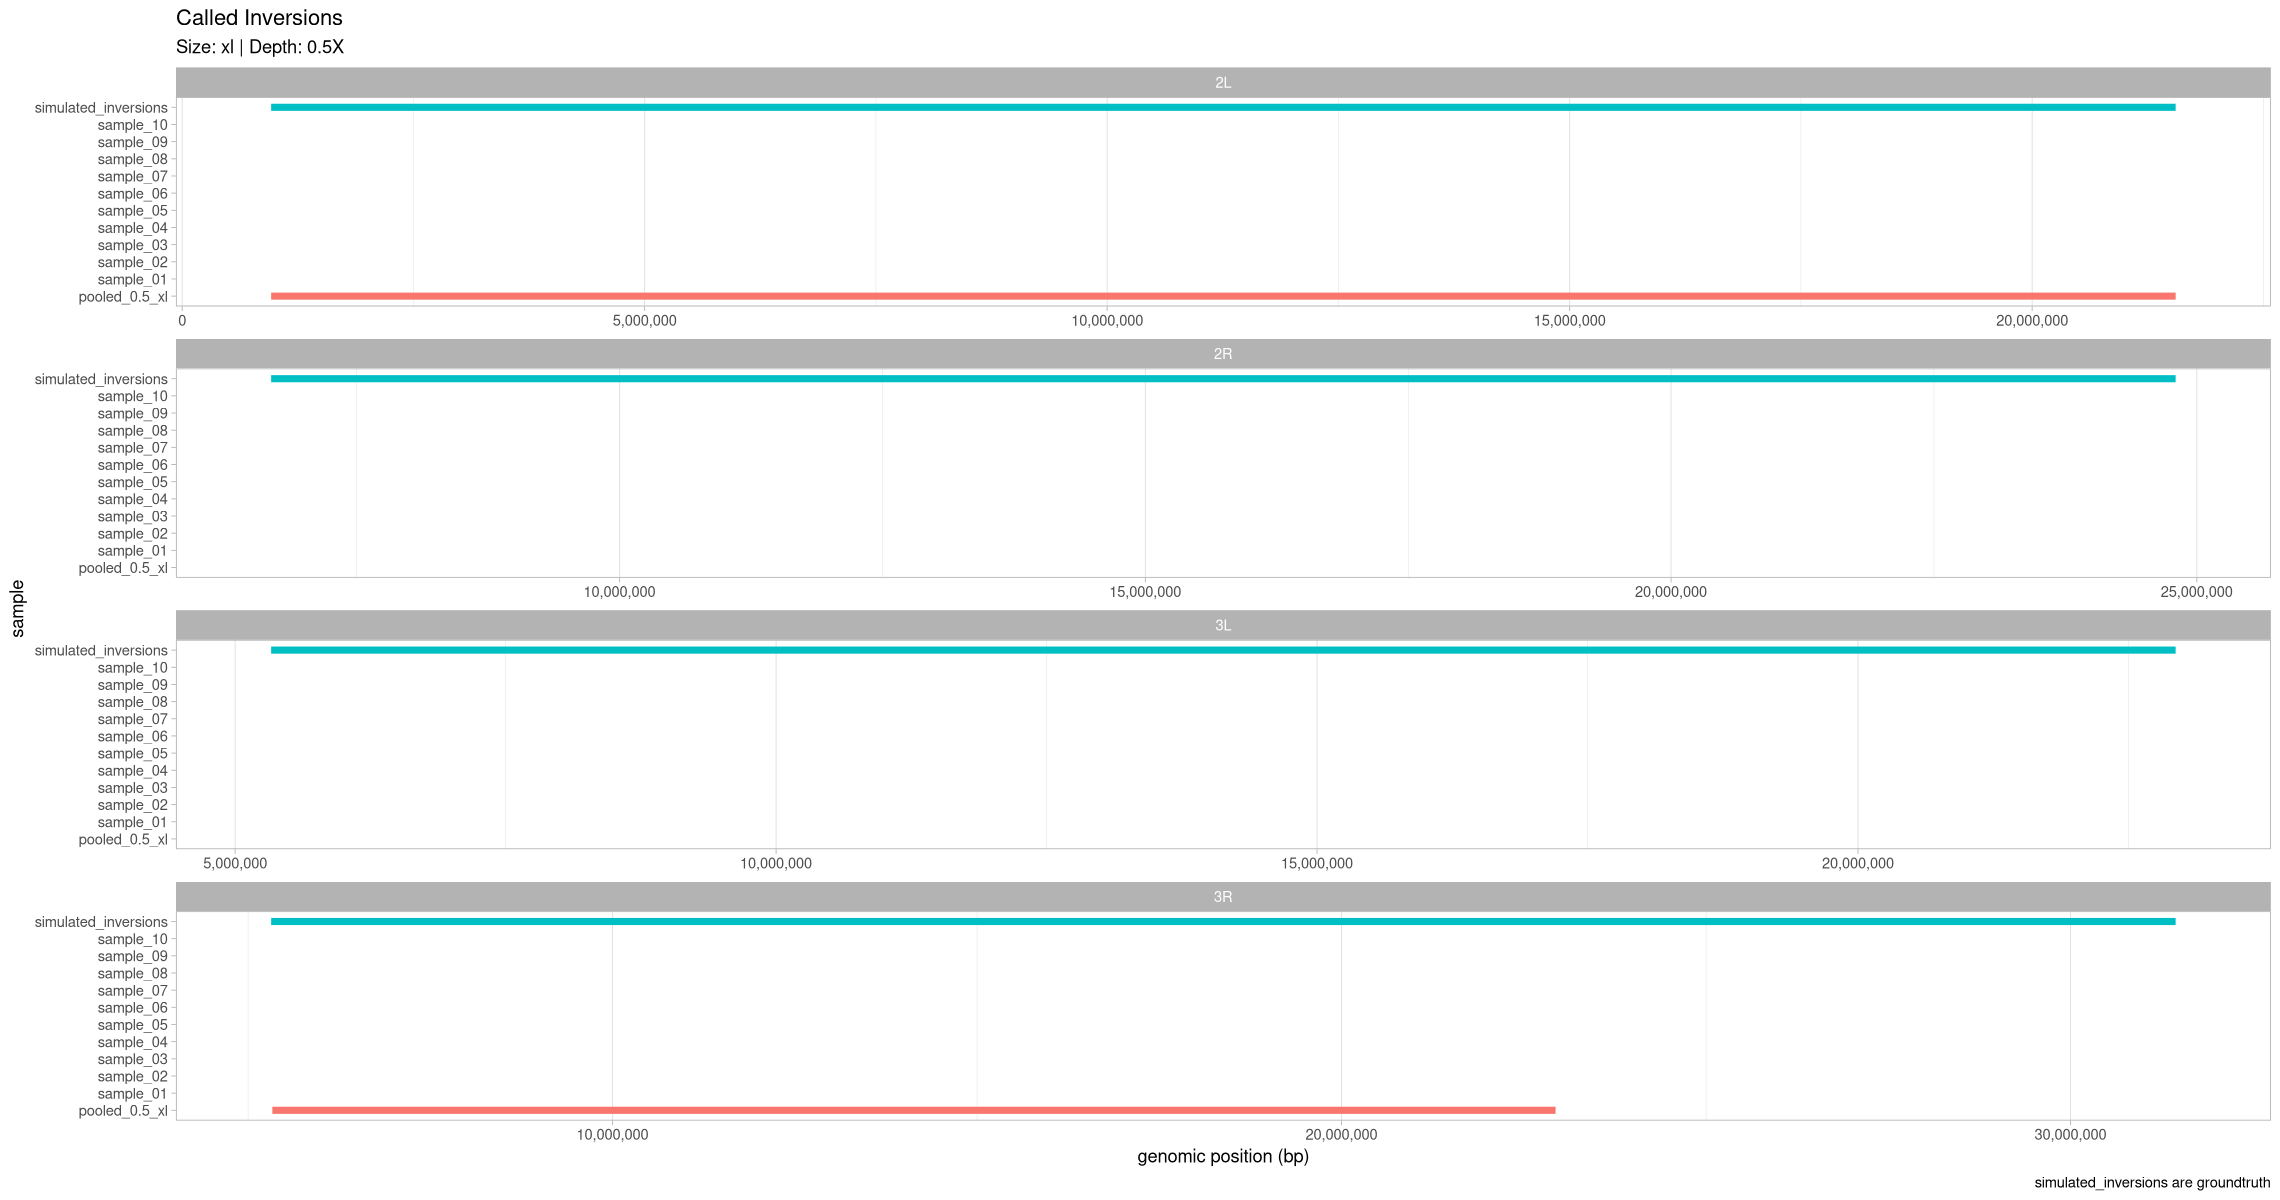

In [4]:
plot_data(depth_05X, .size, 0.5)

## 2X Depth

In [5]:
depth_2X <- read_data(.size, 2)
tail(depth_2X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
8,2R,6686007,24798525,sample_01
9,3R,5332917,22935558,sample_01
10,2L,961650,21551190,sample_03
11,2L,961650,21551190,pooled_2_xl
12,2R,6686006,24798524,pooled_2_xl
13,3R,5332917,22935558,pooled_2_xl


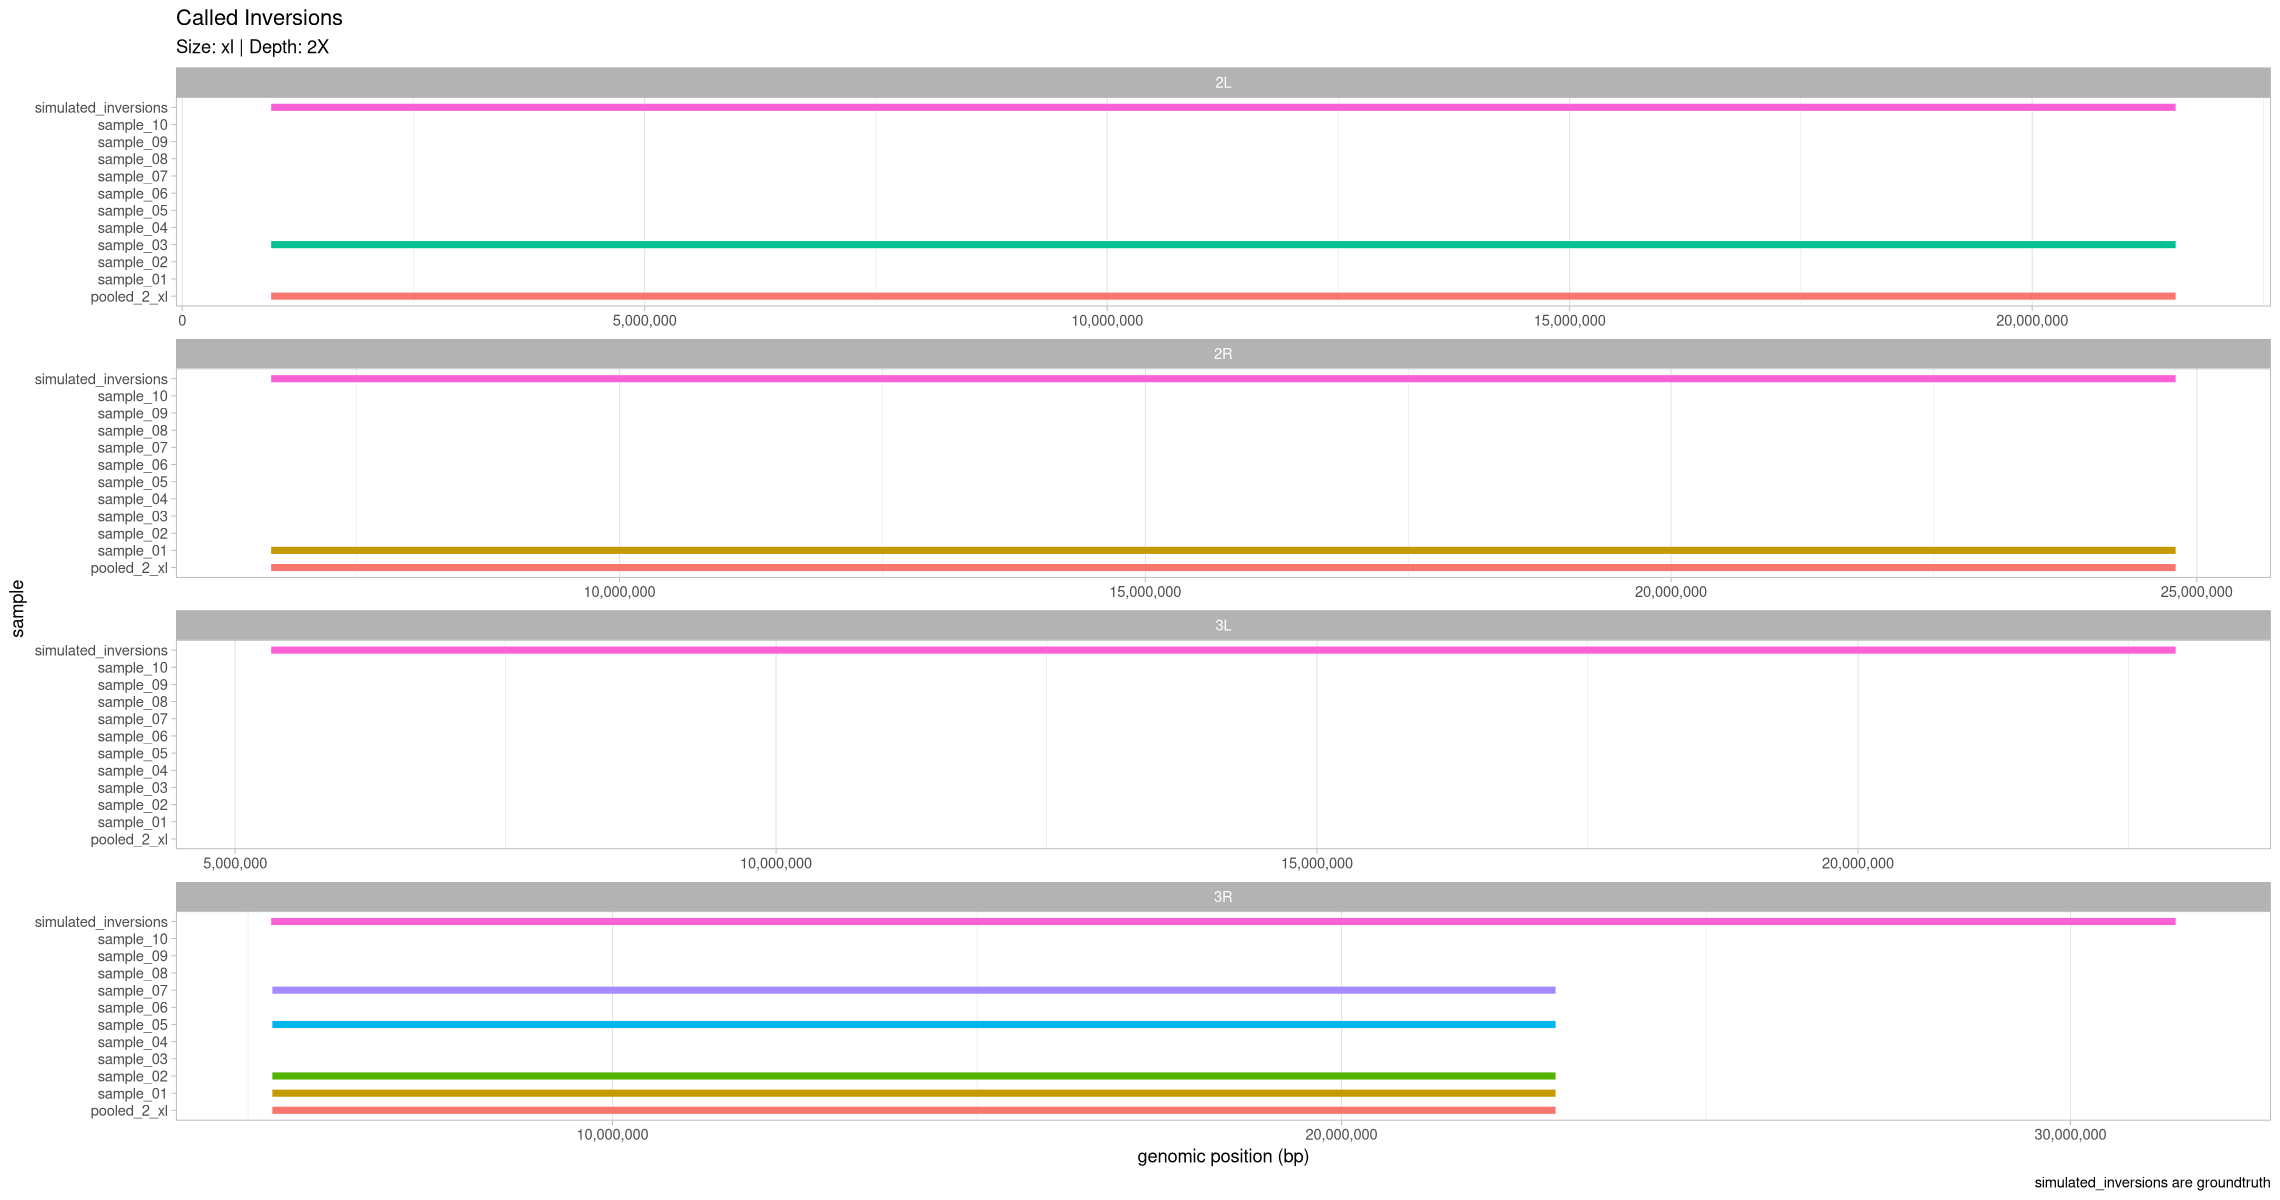

In [6]:
plot_data(depth_2X, .size, 2)

## 5X Depth

In [7]:
depth_5X <- read_data(.size, 5)
tail(depth_5X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
24,3R,5332917,22935558,sample_05
25,2L,961650,21551190,pooled_5_xl
26,3L,5332915,22935558,pooled_5_xl
27,2R,6686006,24798524,pooled_5_xl
28,3R,5316415,31441385,pooled_5_xl
29,3R,5332917,22935558,pooled_5_xl


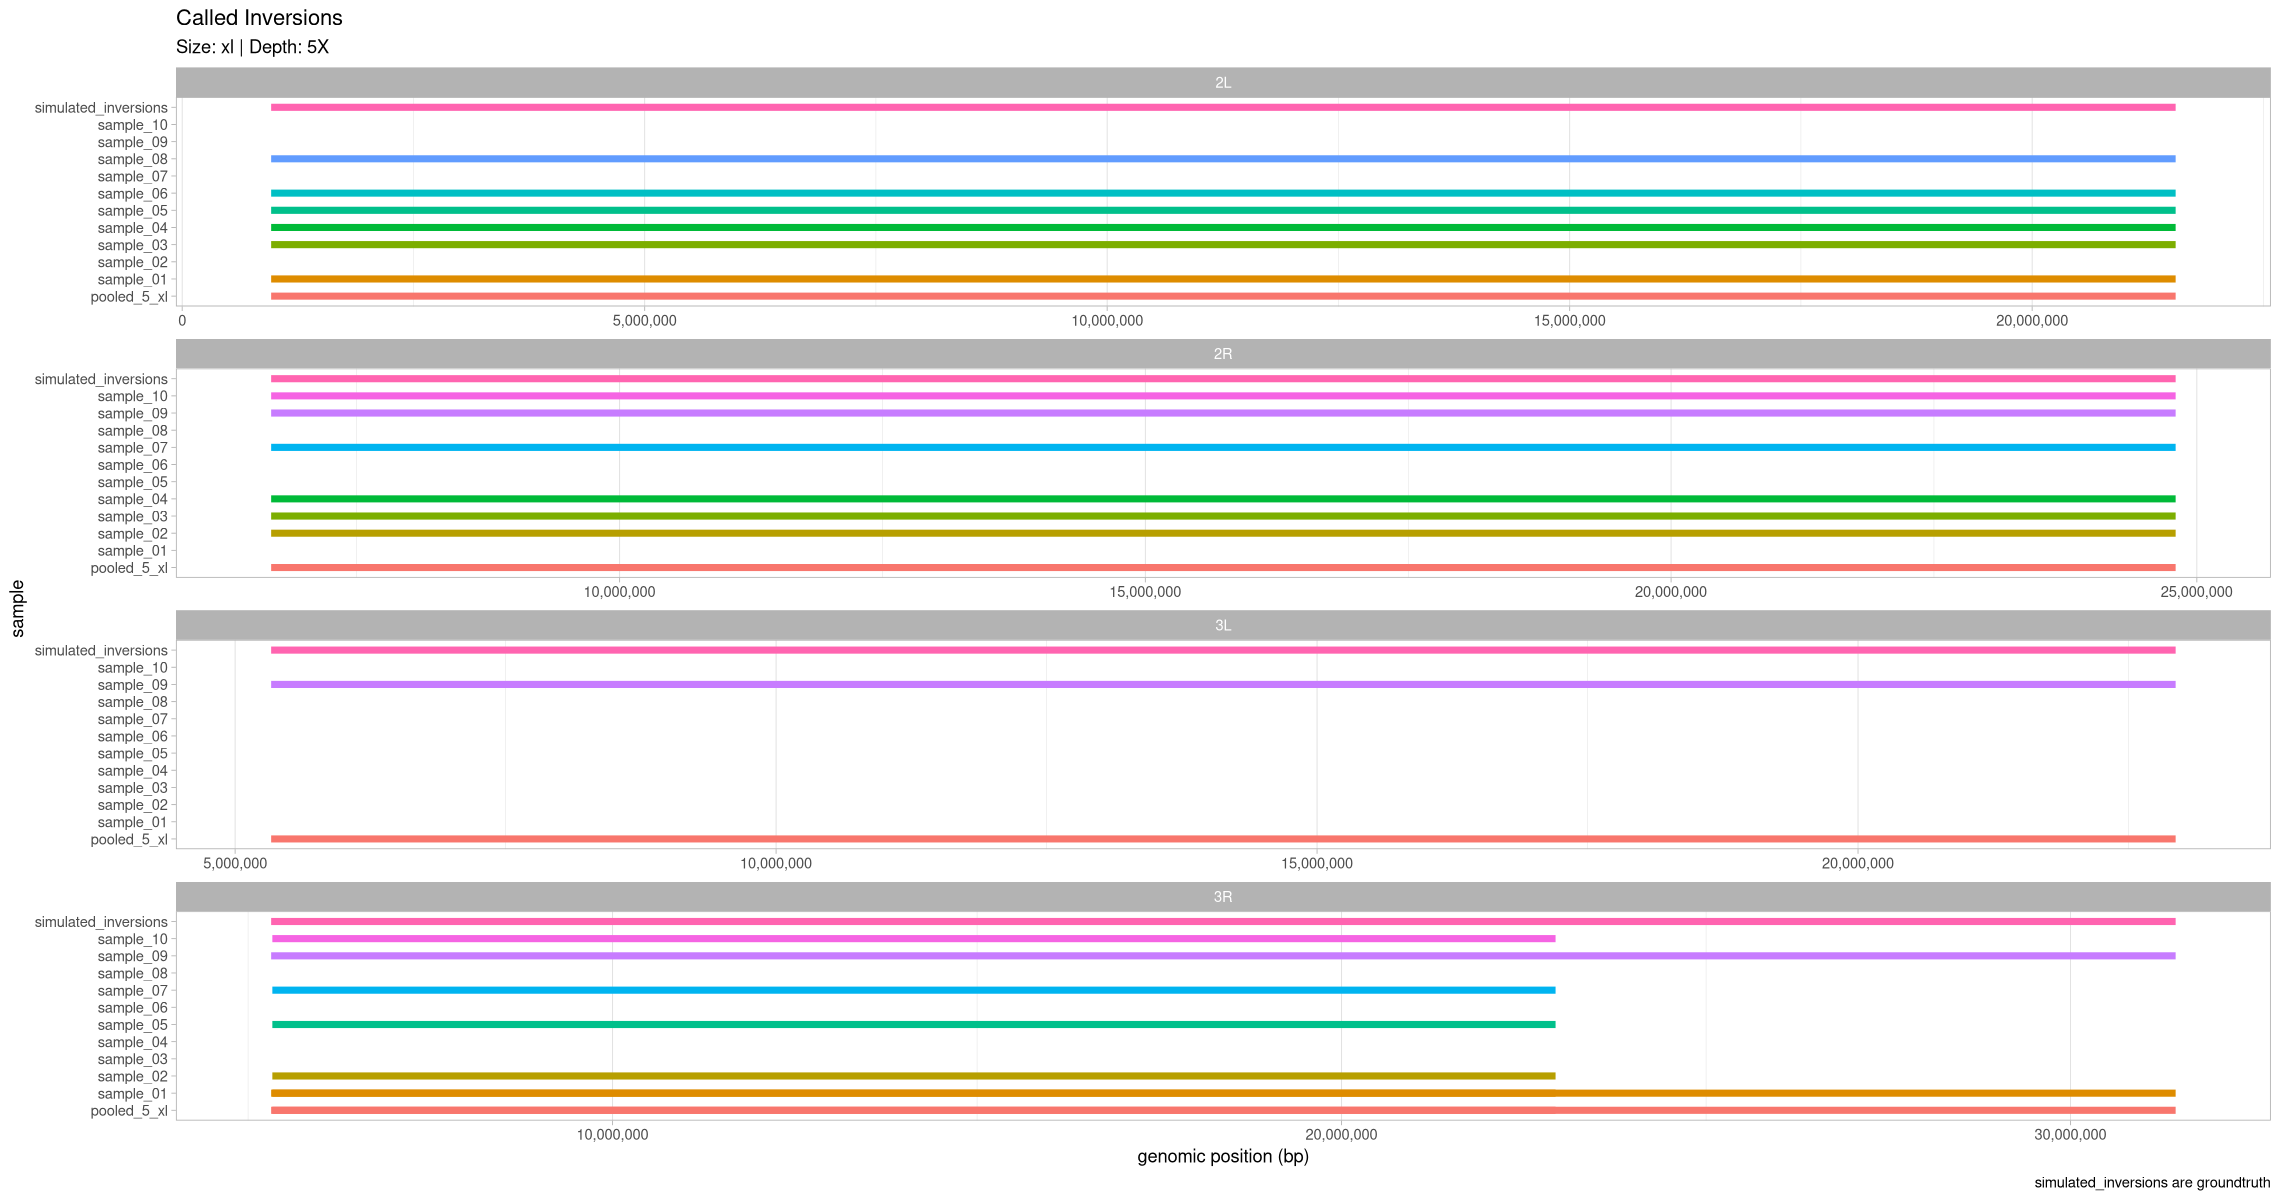

In [8]:
plot_data(depth_5X, .size, 5)

## 10X Depth

In [9]:
depth_10X <- read_data(.size, 10)
tail(depth_10X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
33,2L,961650,21551190,sample_04
34,2R,6686006,24798524,sample_04
35,2L,961650,21551190,pooled_10_xl
36,2R,6686007,24798524,pooled_10_xl
37,3R,5316415,31441385,pooled_10_xl
38,3R,5332917,22935558,pooled_10_xl


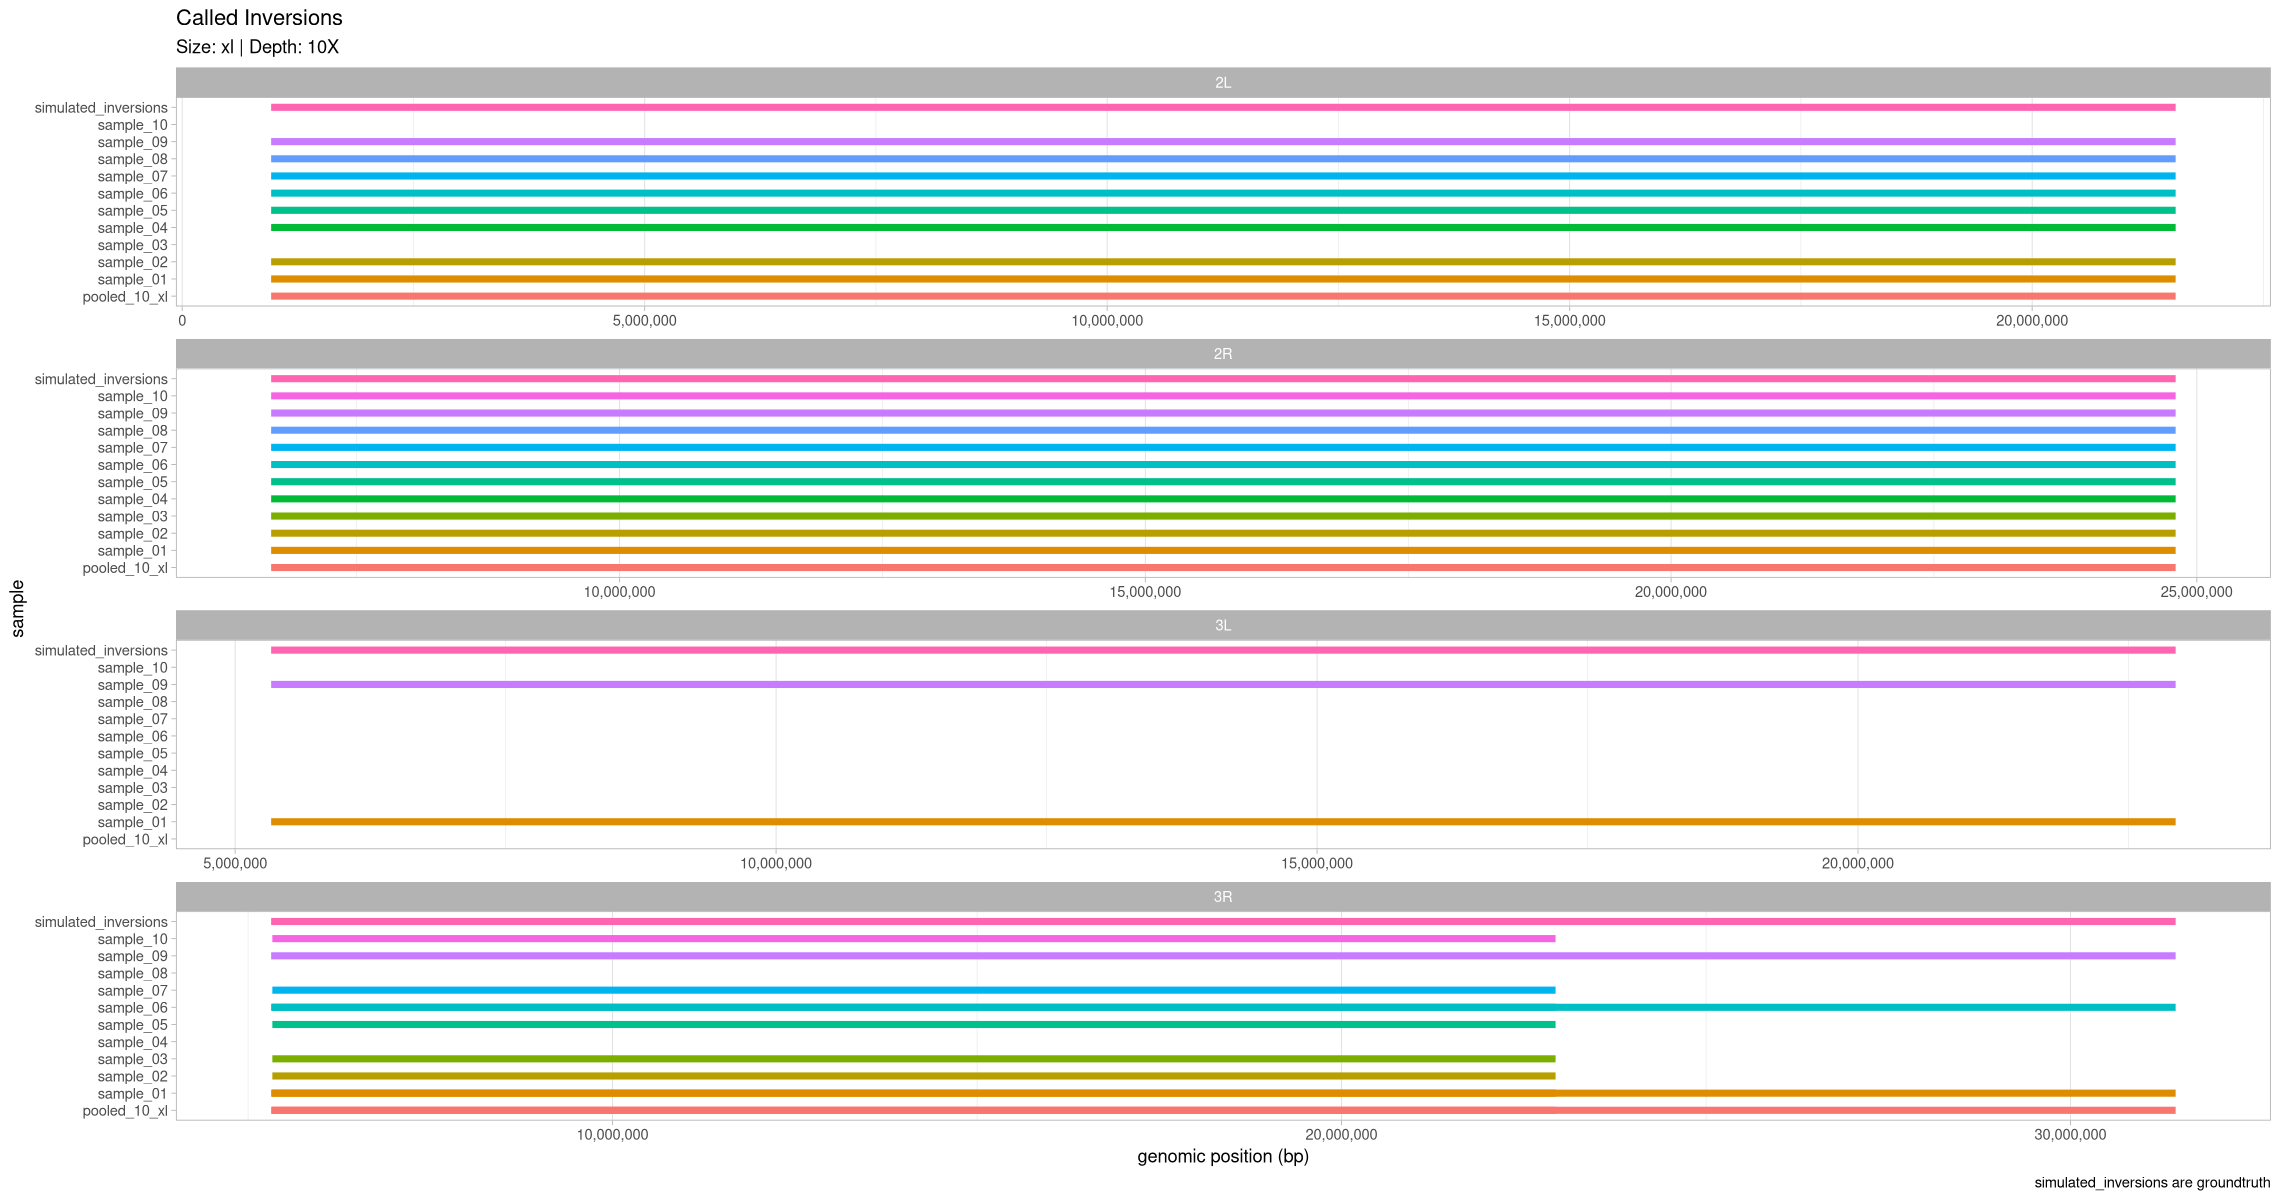

In [10]:
plot_data(depth_10X, .size, 10)

## 20X Depth

In [11]:
depth_20X <- read_data(.size, 20)
tail(depth_20X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
36,3R,5332917,22935558,sample_05
37,2L,961650,21551190,pooled_20_xl
38,3L,5332915,22935560,pooled_20_xl
39,2R,6686007,24798524,pooled_20_xl
40,3R,5316415,31441385,pooled_20_xl
41,3R,5332917,22935558,pooled_20_xl


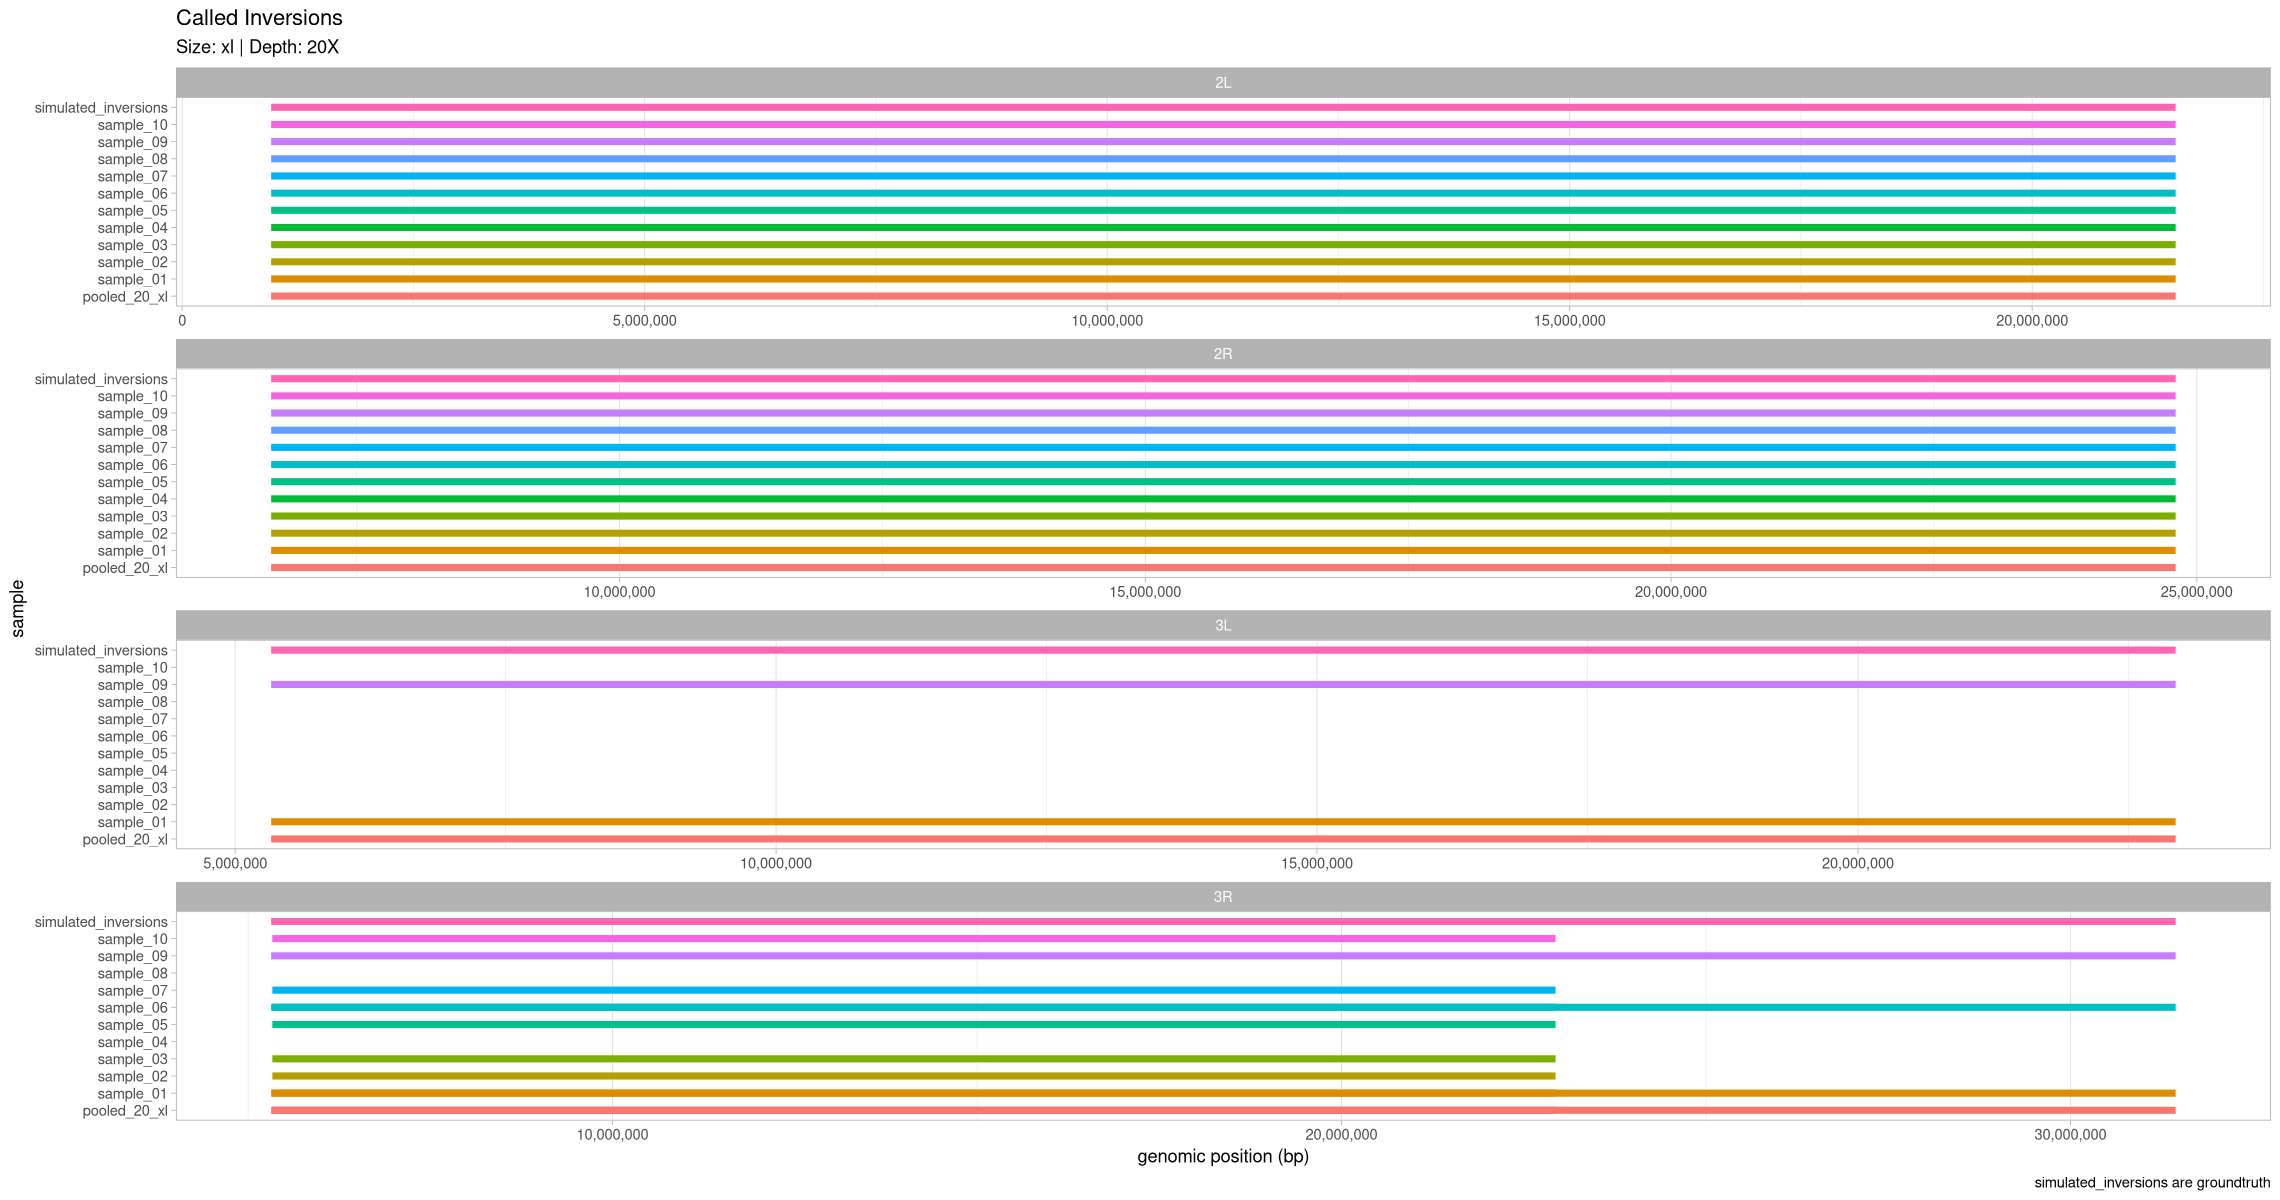

In [12]:
plot_data(depth_20X, .size, 20)